# House Price Prediction using Linear Regression

## Project Description

The objective of this project is to build a machine learning model to predict house prices based on various features such as the size of the house, number of rooms, location, quality, year built, and other property-related characteristics.

In this project, we will perform data exploration and cleaning, handle missing values, encode categorical variables, analyze relationships between features, and build a Linear Regression model.

The model will be evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. We will also visualize the actual and predicted prices and analyze the model coefficients to understand the factors affecting house prices.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## Dataset

The dataset used is the **House Prices - Advanced Regression Techniques** dataset from Kaggle. The target variable is `SalePrice`, which represents the sale price of each house.

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.Load The Dataset

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Suyog\OneDrive\Desktop\Oasis\train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2.Exploratory Data Analysis

In [9]:
df.shape

(1460, 81)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

## 3.Missing Values Analysis

In [11]:
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [12]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

missing

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [13]:
missing.shape

(19,)

## 4.Descriptive Statistics

In [16]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


## 5.SalePrice Distribution

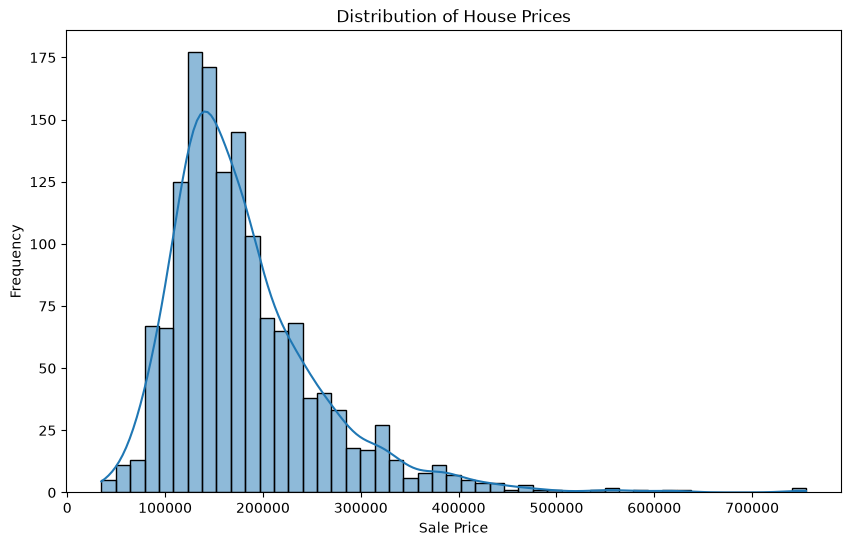

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Observation: SalePrice Distribution

The distribution of SalePrice is right-skewed, indicating that most houses are sold at relatively lower prices while a smaller number of houses have considerably higher prices. The dataset also contains a few high-priced properties that may act as outliers.

## 6. Correlation Analysis and Heatmap
### Objective

#Correlation analysis is used to identify numerical features that have a strong relationship with the target variable `SalePrice`. This helps us understand which features may be useful predictors for the house price prediction model.

In [9]:
correlation = df.select_dtypes(include=np.number).corr()["SalePrice"].sort_values(ascending=False)

correlation

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [10]:
top_corr = correlation.head(11)
top_corr

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

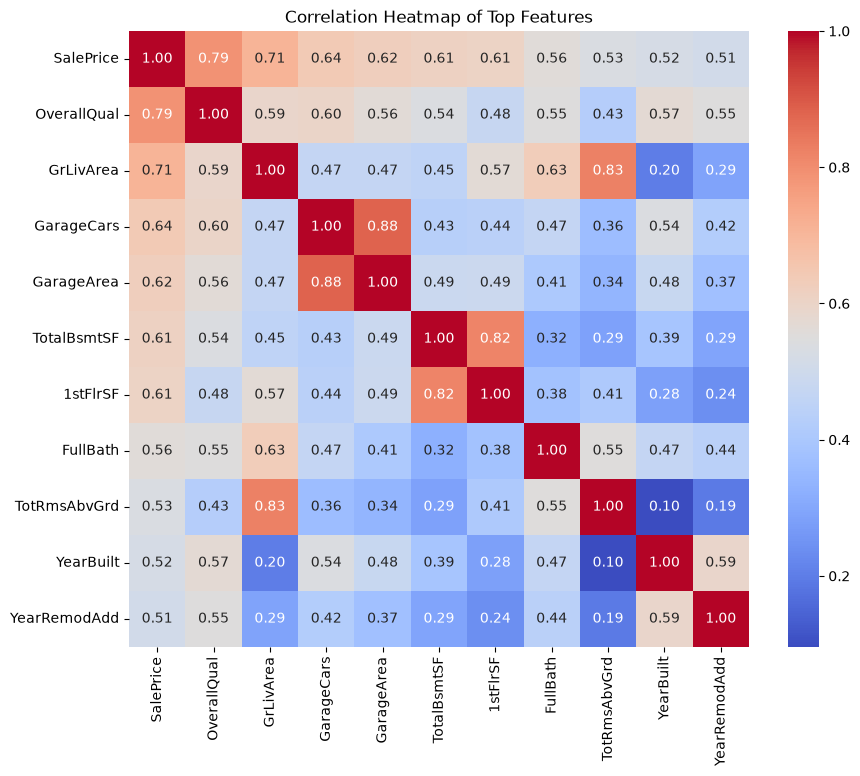

In [11]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df[top_corr.index].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Top Features")
plt.show()

### Observation

The correlation analysis shows the strength and direction of the relationship between numerical features and `SalePrice`. Features with higher positive correlation with `SalePrice` are potentially useful predictors for the house price prediction model.

## 7. Feature Selection

In [14]:
# Select top 10 features based on correlation with SalePrice

selected_features = correlation.drop("SalePrice").head(10)

selected_features

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

## 8. Data Cleaning and Handling Missing Values



In [15]:
# Check missing values in the dataset
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [16]:
# Fill missing categorical values with "None"
categorical_none = [
    "PoolQC", "MiscFeature", "Alley", "Fence",
    "MasVnrType", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "BsmtQual", "BsmtCond"
]

for col in categorical_none:
    df[col] = df[col].fillna("None")

print("Categorical missing values handled.")

Categorical missing values handled.


In [17]:
# Fill numerical missing values

df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

print("Numerical missing values handled.")

Numerical missing values handled.


In [18]:
# Fill the missing Electrical value with the most frequent value

df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

print("Electrical missing value handled.")

Electrical missing value handled.


In [19]:
# Check remaining missing values

remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

remaining_missing

Series([], dtype: int64)

## 9.One-Hot Encoder

In [20]:
# Separate features and target variable

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1460, 80)
Target shape: (1460,)


In [22]:
# Identify categorical columns

categorical_columns = X.select_dtypes(include=["str"]).columns

print("Number of categorical columns:", len(categorical_columns))
print("Categorical columns:")
print(list(categorical_columns))

Number of categorical columns: 43
Categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [27]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [28]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify numerical columns
numerical_columns = X.select_dtypes(include=["number"]).columns

# Create One-Hot Encoder
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

# Transform the features
X_encoded = preprocessor.fit_transform(X)

print("Original features:", X.shape[1])
print("Encoded features:", X_encoded.shape[1])

Original features: 80
Encoded features: 303


## 10.Train-Test Split


In [29]:
from sklearn.model_selection import train_test_split

# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 303)
Testing data: (292, 303)


## 11.Linear Regression Model

In [30]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 12.Price Prediction

In [31]:
# Predict house prices for the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 5 predicted prices:")
print(y_pred[:5])

Predictions generated successfully!
First 5 predicted prices:
[157113.0593363  349123.73600519  92429.86524665 181627.8853688
 341772.63542899]


## 13.Calculate MSE, RMSE, and R²

In [32]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 966016917.3849732
Root Mean Squared Error (RMSE): 31080.81268861825
R² Score: 0.8740579094954513


### Model Evaluation

The Linear Regression model achieved an R² Score of 0.8741, indicating that approximately 87.4% of the variation in house prices is explained by the model.

The RMSE is 31,080.81, which represents the typical magnitude of prediction error in the same units as the target variable, `SalePrice`.


## 14.Actual vs Predicted Prices

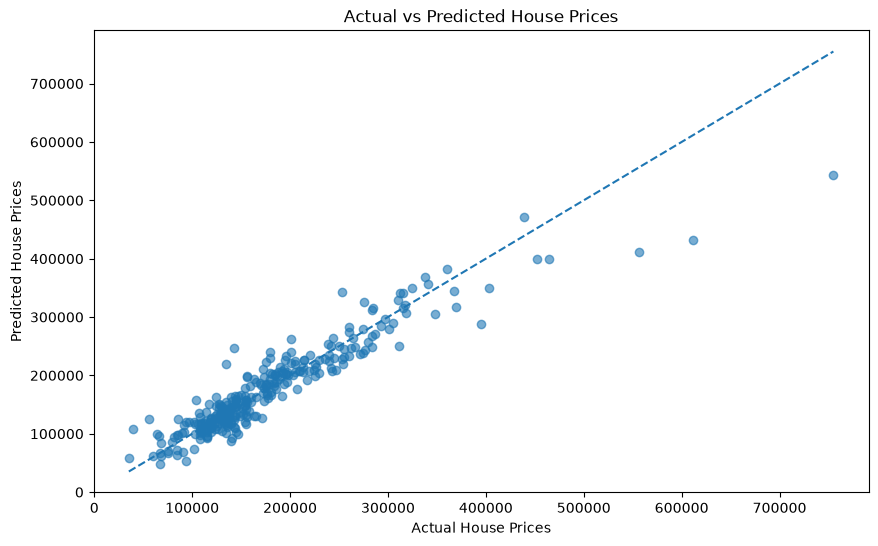

In [33]:
# Plot Actual vs Predicted House Prices

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

### Observation: Actual vs Predicted Prices

The scatter plot shows a strong relationship between actual and predicted house prices. Most data points are located close to the diagonal reference line, indicating that the Linear Regression model provides reasonably accurate predictions.

Some points are farther from the reference line, especially for higher-priced houses, indicating larger prediction errors for a few properties.

## 15. Residual Analysis

In [35]:
# Calculate residuals

residuals = y_test - y_pred

print("First 5 residuals:")
print(residuals.head())

First 5 residuals:
892     -2613.059336
1105   -24123.736005
413     22570.134753
522    -22627.885369
1036   -26272.635429
Name: SalePrice, dtype: float64


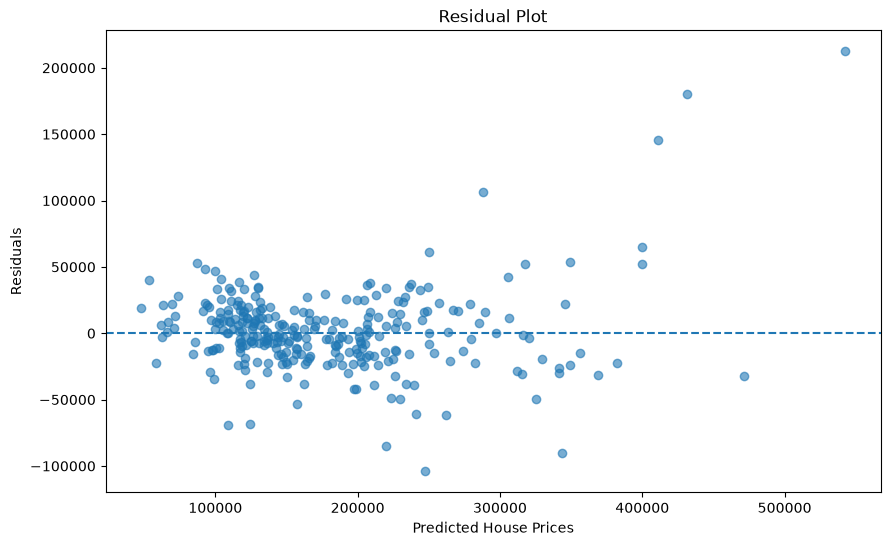

In [36]:
# Plot residuals

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted House Prices")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

### Observation: Residual Plot

The residuals are generally scattered around the zero reference line, indicating that the model errors are distributed around zero for many observations.

However, some larger positive and negative residuals are visible, particularly for houses with higher predicted prices. These points indicate that the model has larger prediction errors for a few properties.

## 16. Coefficient Analysis

In [37]:
# Get feature names after One-Hot Encoding

feature_names = preprocessor.get_feature_names_out()

# Get Linear Regression coefficients
coefficients = model.coef_

# Create a DataFrame of features and coefficients
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient
coef_df = coef_df.sort_values("Coefficient", ascending=False)

coef_df.head(10)

,Feature,Coefficient
80,cat__Neighborhood_NoRidge,38467.702492
87,cat__Neighborhood_StoneBr,32993.803611
81,cat__Neighborhood_NridgHt,22845.425601
137,cat__Exterior1st_BrkFace,21823.266763
184,cat__BsmtQual_Ex,20294.842064
231,cat__KitchenQual_Ex,19941.071042
274,cat__PoolQC_Ex,18929.376396
52,cat__LandContour_HLS,18724.163993
156,cat__Exterior2nd_ImStucc,18685.391225
71,cat__Neighborhood_Crawfor,17531.764505


### Observation: Coefficient Analysis

The coefficient analysis shows that several encoded categorical features have relatively large positive coefficients in the Linear Regression model.

`Neighborhood_NoRidge` has the highest positive coefficient among the displayed features, followed by `Neighborhood_StoneBr` and `Neighborhood_NridgHt`.

Other features such as `Exterior1st_BrkFace`, `BsmtQual_Ex`, and `KitchenQual_Ex` also have positive coefficients.

These coefficients indicate the direction and estimated contribution of these encoded features to the model's predicted `SalePrice`, while keeping other features constant.

## 17. Ridge and Lasso Regression.

In [38]:
from sklearn.linear_model import Ridge

# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train, y_train)

# Make predictions
ridge_pred = ridge_model.predict(X_test)

print("Ridge Regression predictions generated successfully!")

Ridge Regression predictions generated successfully!


In [39]:
# Evaluate Ridge Regression

ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge MSE:", ridge_mse)
print("Ridge RMSE:", ridge_rmse)
print("Ridge R² Score:", ridge_r2)

Ridge MSE: 1181498954.609625
Ridge RMSE: 34372.939278008
Ridge R² Score: 0.8459649664570256


### Observation: Ridge Regression

The Ridge Regression model achieved an R² Score of approximately 0.8460 and an RMSE of approximately 34,372.94 on the test dataset.

The model provides a reasonable fit to the test data while applying regularization to control the size of the regression coefficients.

16B. Lasso Regression

In [42]:
from sklearn.linear_model import Lasso

# Create Lasso Regression model with more iterations
lasso_model = Lasso(alpha=1.0, max_iter=100000)

# Train the model
lasso_model.fit(X_train, y_train)

# Make predictions
lasso_pred = lasso_model.predict(X_test)

print("Lasso Regression predictions generated successfully!")

Lasso Regression predictions generated successfully!


In [43]:
# Evaluate Lasso Regression

lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso MSE:", lasso_mse)
print("Lasso RMSE:", lasso_rmse)
print("Lasso R² Score:", lasso_r2)

Lasso MSE: 1928250105.654398
Lasso RMSE: 43911.84470794182
Lasso R² Score: 0.748609113410637


In [44]:
# Compare all three regression models

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MSE": [mse, ridge_mse, lasso_mse],
    "RMSE": [rmse, ridge_rmse, lasso_rmse],
    "R² Score": [r2, ridge_r2, lasso_r2]
})

comparison

,Model,MSE,RMSE,R² Score
0,Linear Regression,9.660169e+08,31080.812689,0.874058
1,Ridge Regression,1.181499e+09,34372.939278,0.845965
2,Lasso Regression,1.928250e+09,43911.844708,0.748609


## Model Comparison

The three regression models were evaluated using MSE, RMSE, and R² Score. These metrics help compare the prediction errors and overall performance of the models.

### Observation

The three regression models produced different MSE, RMSE, and R² Score values on the test dataset.

Linear Regression achieved an R² Score of 0.8741 with an RMSE of 31,080.81. Ridge Regression achieved an R² Score of 0.8460 with an RMSE of 34,372.94, while Lasso Regression achieved an R² Score of 0.7486 with an RMSE of 43,911.84.

These metrics provide a quantitative basis for comparing the prediction performance of the three regression models.

### Conclusion

In this project, a Linear Regression model was developed to predict house prices using the Ames Housing dataset. The data was explored, missing values were handled, and categorical variables were converted using One-Hot Encoding before training the models.

The Linear Regression model achieved an R² score of 0.8741 and an RMSE of 31,080.81 on the test dataset. This indicates that the model was able to explain a substantial portion of the variation in house prices.

Ridge and Lasso Regression were also tested as regularized alternatives. Their performance was evaluated using the same MSE, RMSE, and R² metrics to understand how regularization affected the predictions.

Overall, this project provided an end-to-end understanding of preparing housing data, selecting relevant predictors, training regression models, evaluating predictions, and interpreting model results.